In [2]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
"""
pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)
"""
sns.set_theme()

In [3]:
os.chdir("/Users/felixdiederichs/PycharmProjects/Data_Analysis/.venv/Analyse/Obesity")

data_resemblance = pd.read_csv('obesity_resemblance.csv')
data_fairness = pd.read_csv('obesity_fairness.csv')

data_resemblance['id'] = range(len(data_resemblance))
data_fairness['id'] = range(len(data_fairness))

df_merge = pd.merge(data_resemblance, data_fairness, on='id')
df_merge.rename({'Model_x': 'Model'}, axis='columns', inplace=True)

df_merge_tabfairgan = df_merge[df_merge['Model'] == 'tabfairgan']
df_merge_distcorrgan = df_merge[df_merge['Model'] == 'distcorrgan']
df_merge_multifairgan = df_merge[df_merge['Model'] == 'multifairgan']
df_merge_decaf = df_merge[df_merge['Model'] == 'decaf']
df_merge_tvae = df_merge[df_merge['Model'] == 'tvae']
df_merge_ctgan = df_merge[df_merge['Model'] == 'ctgan']

df_merge

,Model,Epochs,Lambda,Proportion positive numerical tests,Proportion positive categorical tests,Proportion distances below threshold,Proportion positive numerical correlations,Proportion positive categorical correlations,Average DLA,Proportion positive numerical tests 2,...,Lambda,AUC Difference,Balanced Accuracy Difference,Balanced Accuracy Ratio,Disparate Impact Ratio,Equal Odds Difference,Equal Odds Ratio,Positive Predictive Parity Difference,Positive Predictive Parity Ratio,Statistical Parity Difference
0,tabfairgan,50,0.2,0.308333,0.033333,0.845833,0.626,0.543,0.793393,Good,...,0.2,-0.00705,-0.00705,0.99159,0.91645,-0.07018,0.91214,-0.05716,0.93201,-0.06615
1,tabfairgan,50,0.4,0.275000,0.033333,0.858333,0.602,0.489,0.793218,Good,...,0.4,-0.00145,-0.00145,1.00499,0.92823,-0.08715,0.92718,-0.07078,0.91479,-0.05603
2,tabfairgan,50,0.6,0.250000,0.077778,0.841667,0.597,0.474,0.793478,Good,...,0.6,-0.03136,-0.03136,0.94774,0.88309,-0.07983,0.91660,-0.11046,0.86857,-0.09610
3,tabfairgan,50,0.8,0.304167,0.111111,0.850000,0.610,0.586,0.785270,Good,...,0.8,0.00567,0.00546,1.01259,0.86213,-0.11330,0.83476,-0.11098,0.86856,-0.10740
4,tabfairgan,50,1.0,0.262500,0.022222,0.841667,0.583,0.566,0.796911,Good,...,1.0,-0.01271,-0.01271,0.98133,0.84662,-0.12651,0.83492,-0.07999,0.90302,-0.11910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,ctgan,100,NaN,0.241667,0.011111,0.887500,0.608,0.493,0.812313,Good,...,NaN,0.03482,0.03482,1.07186,0.91564,-0.09345,0.86958,-0.03153,0.96318,-0.05969
158,ctgan,150,NaN,0.220833,0.011111,0.883333,0.621,0.516,0.807785,Good,...,NaN,-0.00399,-0.00399,0.99789,0.90720,-0.07245,0.91805,-0.09028,0.89506,-0.07805
159,ctgan,200,NaN,0.220833,0.033333,0.870833,0.618,0.561,0.806137,Good,...,NaN,0.00355,0.00355,1.01392,0.90450,-0.04227,0.96127,-0.12497,0.84179,-0.07132
160,ctgan,250,NaN,0.183333,0.044444,0.875000,0.662,0.514,0.805369,Good,...,NaN,-0.02077,-0.02077,0.96618,0.75723,-0.16182,0.77776,-0.18840,0.76196,-0.18311


<Axes: xlabel='Order Sorted', ylabel='Statistical Parity Difference'>

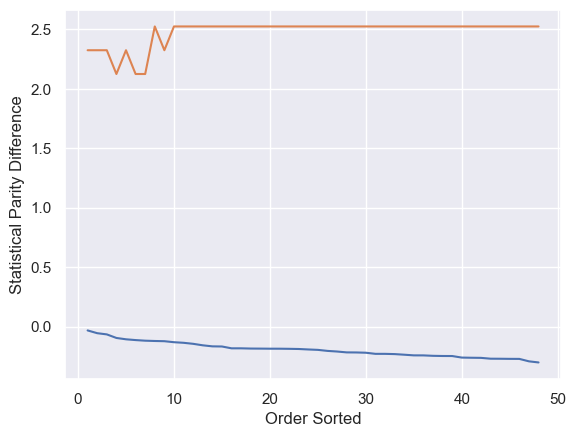

In [5]:
"""data_merged_multifairgan = data_merged[data_merged['Model'] == 'multifairgan']
data_merged_multifairgan_sorted = data_merged_multifairgan.sort_values('Average Statistical Parity Difference', ascending = False)
data_merged_multifairgan_sorted['Order Sorted'] = range(1, len(data_merged_multifairgan_sorted) + 1)

sns.lineplot(x = 'Order Sorted', y = 'Average Statistical Parity Difference', data = data_merged_multifairgan_sorted, errorbar=None)
sns.lineplot(x = 'Order Sorted', y = 'Overall Score', data = data_merged_multifairgan_sorted, errorbar=None)
sns.lineplot(x = 'Order Sorted', y = 'Accuracy 1', data = data_merged_multifairgan_sorted, errorbar=None)"""



df_merge_tabfairgan_sorted = df_merge_tabfairgan.sort_values('Statistical Parity Difference', ascending=False)
df_merge_tabfairgan_sorted['Order Sorted'] = range(1, len(df_merge_tabfairgan_sorted) + 1)

sns.lineplot(x='Order Sorted', y='Statistical Parity Difference', data=df_merge_tabfairgan_sorted)
sns.lineplot(x='Order Sorted', y='Overall Score', data=df_merge_tabfairgan_sorted)